# Wepon Detection using YOLO
-----

In [1]:
# ──────────────────────────────────────────────────────────────
# Install only required packages with pinned versions
# ──────────────────────────────────────────────────────────────

!pip install -q --no-cache-dir \
    torch==2.3.0 torchvision==0.18.0 --extra-index-url https://download.pytorch.org/whl/cu118 \
    "ultralytics>=8.2.0" \
    roboflow \
    pandas==2.1.4 \
    seaborn \
    matplotlib \
    opencv-python-headless \
    pyyaml \
    numpy==1.26.4 \
    scipy==1.13.1

# Verify installations
import torch, numpy as np, pandas as pd, ultralytics
print(f"torch: {torch.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"ultralytics: {ultralytics.__version__}")
print(f"GPU: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.7/839.7 MB 351.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 384.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 46.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 354.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 MB 242.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 MB 271.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 331.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 350.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 200.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 204.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 148.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━


## Import all required modules
## ──────────────────────────────────────────────────────────────

In [2]:

import os                          # File and directory operations (e.g., checking paths)
import yaml                        # Parse YAML files (e.g., data.yaml from Roboflow)
import pandas as pd                # Data manipulation and analysis (e.g., DataFrames for EDA)
import seaborn as sns              # Statistical data visualization (e.g., bar plots, histograms)
import matplotlib.pyplot as plt    # Core plotting library (used with seaborn for EDA charts)
import cv2                         # OpenCV for image loading, processing, and bounding box drawing
import random                      # Random sampling (e.g., selecting sample images for visualization)
import numpy as np                 # Numerical computations (e.g., array operations for image data)
from pathlib import Path           # Object-oriented file paths (cross-platform safe)
from roboflow import Roboflow      # Roboflow SDK for downloading and managing datasets
from ultralytics import YOLO       # Ultralytics YOLO library for model loading, training, and inference
from IPython.display import Image, display  # Jupyter-specific: Display images inline in notebook cells
from collections import defaultdict # Dictionary subclass for counting (e.g., plate counts per image)


# Configure plotting style
sns.set_style("whitegrid")         # Set seaborn theme: white background with grid lines for clean plots
# Verification print
print("All imports successful!")   # Confirm all libraries loaded without errors

All imports successful!


## Download Roboflow Dataset
## ──────────────────────────────────────────────────────────────

In [3]:


from roboflow import Roboflow
rf = Roboflow(api_key="1LXmrHIjxoP1M8QXA59l")
project = rf.workspace("takeoff-kk0rk").project("teting_generade_weapon-mgcov")
version = project.version(1)
dataset = version.download("yolov8")
                
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to teting_generade_weapon-1 in yolov8:: 100%|██████████| 4932/4932 [00:00<00:00, 8447.46it/s]


 The above code loades the image from the roboflow.


## Print folder tree + data.yaml
## ──────────────────────────────────────────────────────────────

In [4]:
def print_tree(path: Path, indent: str = ""):
    for p in sorted(path.iterdir()):
        if p.is_dir():
            print(f"{indent}📁 {p.name}/")
            print_tree(p, indent + "  ")
        else:
            print(f"{indent}📄 {p.name}")



with open("/kaggle/working/teting_generade_weapon-1/data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)
print("\n--- data.yaml ---")
print(yaml.dump(data_cfg, sort_keys=False))


--- data.yaml ---
names:
- Grenade
- Gun
- Handgun
- Knife
nc: 4
roboflow:
  license: CC BY 4.0
  project: teting_generade_weapon-mgcov
  url: https://universe.roboflow.com/takeoff-kk0rk/teting_generade_weapon-mgcov/dataset/1
  version: 1
  workspace: takeoff-kk0rk
test: ../test/images
train: ../train/images
val: ../valid/images



- from that above code we can read the yaml file and will display how many classes inside that and what are those

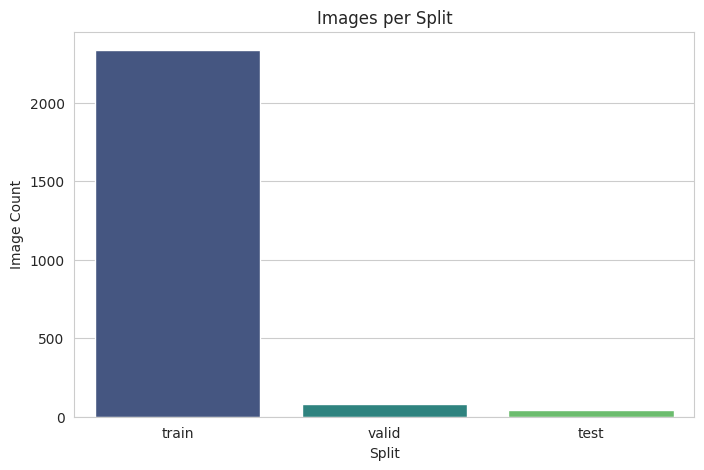

Split  Image Count
train         2334
valid           82
 test           44


In [5]:
DATASET_PATH = Path("/kaggle/working/teting_generade_weapon-1")
# Define a helper function to count images in a given split
def count_images(split: str) -> int:
    """
    Count the number of .jpg images in the images directory of a split.
    
    Args:
        split (str): The dataset split name ('train', 'valid', 'test').
    
    Returns:
        int: Number of image files found.
    """
    # Construct the path to the images directory for the split
    img_dir = DATASET_PATH / split / "images"
    
    # Use glob to find all files matching *.jpg pattern
    # list() forces evaluation to count the matches
    return len(list(img_dir.glob("*.jpg")))

# Define the list of dataset splits to process
splits = ["train", "valid", "test"]

# Use dictionary comprehension to count images for each split
# This creates a dict like {'train': 12000, 'valid': 1500, 'test': 1500}
counts = {s: count_images(s) for s in splits}

# Build a pandas DataFrame from the counts using list comprehension
# Each row is a dict with 'Split' and 'Image Count' keys
# This avoids pandas conversion issues with tuples
df_counts = pd.DataFrame([
    {"Split": s, "Image Count": c} for s, c in counts.items()
])

# Create a new figure for the plot with specified size
plt.figure(figsize=(8, 5))

# Generate a bar plot using seaborn
# x: Split names, y: Image counts, palette: Color scheme
sns.barplot(data=df_counts, x="Split", y="Image Count", palette="viridis")

# Set the title of the plot
plt.title("Images per Split")

# Display the plot
plt.show()

# Print the DataFrame as a formatted table without index
print(df_counts.to_string(index=False))

# Count classes per image
# ──────────────────────────────────────────────────────────────

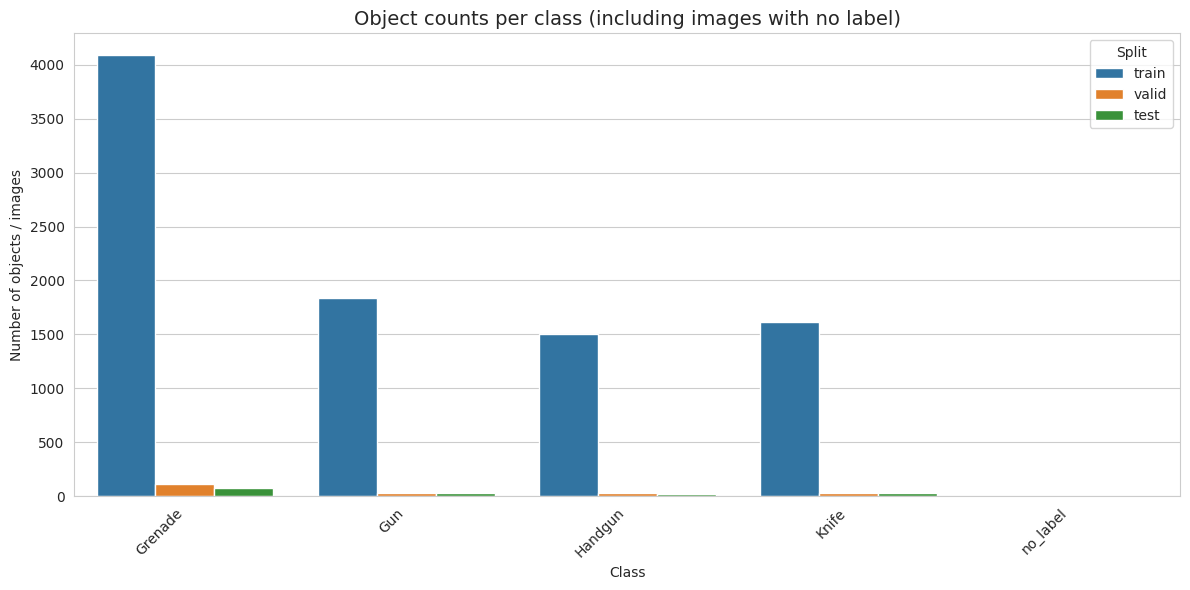


=== Class / No-label summary ===
Split     test  train  valid  Total
Class                              
Grenade     78   4086    112   4276
Gun         33   1833     32   1898
Handgun     25   1503     27   1555
Knife       31   1611     32   1674
no_label     0      0      0      0
Total      167   9033    203   9403


In [6]:
# ----------------------------------------------------------------------
# 1. Imports (add the ones you may be missing)
# ----------------------------------------------------------------------
import yaml
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------------------------------------------------
# 2. Helper: read a single label file and return the list of class ids
# ----------------------------------------------------------------------
def read_labels(label_path: Path):
    """Return list of integer class ids in a YOLO .txt file."""
    if not label_path.exists():
        return []                     # missing txt → no label
    with open(label_path, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    # YOLO format: class_id cx cy w h  (we only need class_id)
    return [int(line.split()[0]) for line in lines if line]

# ----------------------------------------------------------------------
# 3. Load data.yaml → class names
# ----------------------------------------------------------------------
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]          # list like ['cat', 'dog', ...]
n_classes   = len(class_names)

# ----------------------------------------------------------------------
# 4. Iterate over the three splits and collect statistics
# ----------------------------------------------------------------------
splits = ["train", "valid", "test"]

# Containers
class_counts   = {s: np.zeros(n_classes, dtype=int) for s in splits}
no_label_counts = {s: 0 for s in splits}   # images without any annotation

for split in splits:
    img_dir  = DATASET_PATH / split / "images"
    lbl_dir  = DATASET_PATH / split / "labels"

    for img_path in img_dir.glob("*.jpg"):
        # corresponding label file (same stem, .txt extension)
        lbl_path = lbl_dir / (img_path.stem + ".txt")

        class_ids = read_labels(lbl_path)

        if not class_ids:                     # <-- empty or missing label
            no_label_counts[split] += 1
        else:
            # count each occurrence
            uniq, cnts = np.unique(class_ids, return_counts=True)
            class_counts[split][uniq] += cnts

# ----------------------------------------------------------------------
# 5. Build a tidy DataFrame for seaborn
# ----------------------------------------------------------------------
rows = []

# ---- class bars -------------------------------------------------------
for split in splits:
    for cls_idx, name in enumerate(class_names):
        rows.append({
            "Split": split,
            "Class": name,
            "Count": int(class_counts[split][cls_idx])
        })

# ---- no-label bars ----------------------------------------------------
for split in splits:
    rows.append({
        "Split": split,
        "Class": "no_label",
        "Count": no_label_counts[split]
    })

df = pd.DataFrame(rows)

# ----------------------------------------------------------------------
# 6. Plot
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Order classes + the extra "no_label" bar
order = class_names + ["no_label"]

sns.barplot(
    data=df,
    x="Class",
    y="Count",
    hue="Split",
    order=order,
    palette="tab10"
)

plt.title("Object counts per class (including images with no label)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of objects / images")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 7. (Optional) Print a summary table
# ----------------------------------------------------------------------
summary = df.pivot_table(
    index="Class",
    columns="Split",
    values="Count",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Total"
).reindex(order + ["Total"])   # keep desired order

print("\n=== Class / No-label summary ===")
print(summary.to_string())

- as we can see the above, we have not  found any no_labels data.also we can see granade class having more training data

##  DELETE EMPTY LABELS + CORRESPONDING IMAGES
## ──────────────────────────────────────────────────────────────

In [7]:
# ----------------------------------------------------------------------
# 0. Imports (you already have them)
# ----------------------------------------------------------------------
from pathlib import Path
import shutil
import yaml
import pandas as pd

# ----------------------------------------------------------------------
# 1. Paths (same as before)
# ----------------------------------------------------------------------
DATASET_PATH = Path("/kaggle/working/teting_generade_weapon-1")
splits = ["train", "valid", "test"]

# ----------------------------------------------------------------------
# 2. Helper: is a label file empty or missing?
# ----------------------------------------------------------------------
def is_empty_label(label_path: Path) -> bool:
    if not label_path.exists():
        return True
    with open(label_path, "r") as f:
        return all(line.strip() == "" or line.strip().startswith("#") for line in f)

# ----------------------------------------------------------------------
# 3. Remove un-labelled images + their label files
# ----------------------------------------------------------------------
removed = {s: 0 for s in splits}

for split in splits:
    img_dir = DATASET_PATH / split / "images"
    lbl_dir = DATASET_PATH / split / "labels"

    for img_path in img_dir.glob("*.jpg"):
        lbl_path = lbl_dir / (img_path.stem + ".txt")

        if is_empty_label(lbl_path):
            # ---- delete image + label (if it exists) ----
            img_path.unlink()               # remove .jpg
            if lbl_path.exists():
                lbl_path.unlink()           # remove .txt (even if empty)
            removed[split] += 1

print("Removed images (no label):")
for s, n in removed.items():
    print(f"  {s:5}: {n}")

# ----------------------------------------------------------------------
# 4. (Optional) Re-count images to confirm the drop
# ----------------------------------------------------------------------
def count_images(split: str) -> int:
    return len(list((DATASET_PATH / split / "images").glob("*.jpg")))

new_counts = {s: count_images(s) for s in splits}
print("\nNew image counts after clean-up:")
for s, n in new_counts.items():
    print(f"  {s:5}: {n}")

Removed images (no label):
  train: 0
  valid: 0
  test : 0

New image counts after clean-up:
  train: 2334
  valid: 82
  test : 44


- if we have no label data that can be removed by using that

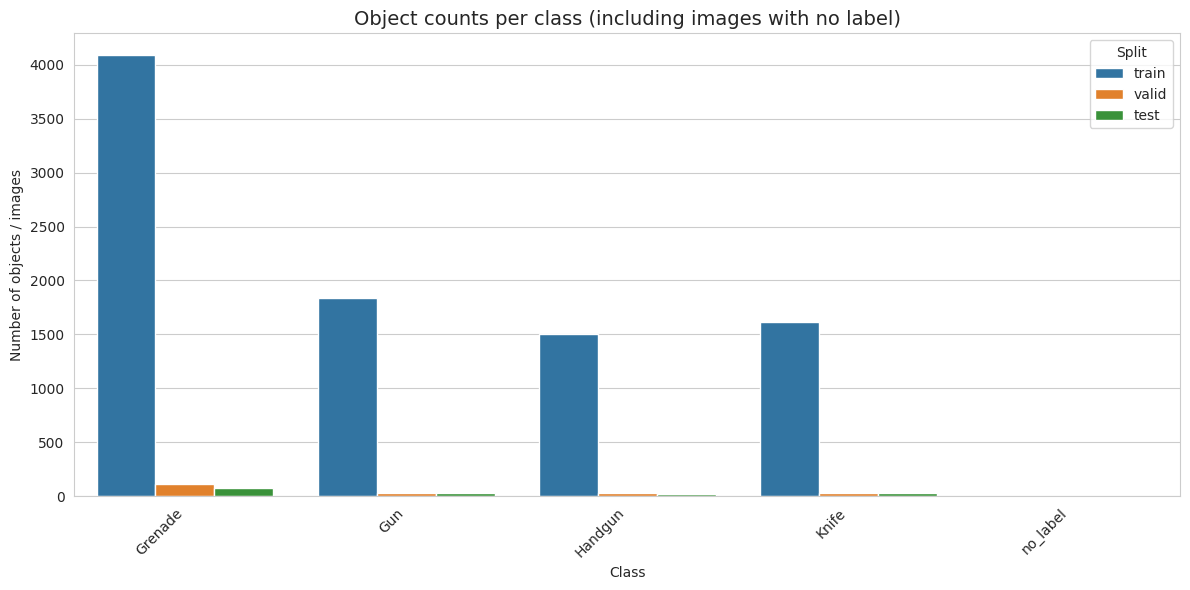


=== Class / No-label summary ===
Split     test  train  valid  Total
Class                              
Grenade     78   4086    112   4276
Gun         33   1833     32   1898
Handgun     25   1503     27   1555
Knife       31   1611     32   1674
no_label     0      0      0      0
Total      167   9033    203   9403


In [8]:
# ──────────────────────────────────────────────────────────────
# VERIFY: Re-check classes per image (should show 0 for Plates=0)
# ──────────────────────────────────────────────────────────────
# ----------------------------------------------------------------------
# 1. Imports (add the ones you may be missing)
# ----------------------------------------------------------------------
import yaml
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------------------------------------------------
# 2. Helper: read a single label file and return the list of class ids
# ----------------------------------------------------------------------
def read_labels(label_path: Path):
    """Return list of integer class ids in a YOLO .txt file."""
    if not label_path.exists():
        return []                     # missing txt → no label
    with open(label_path, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    # YOLO format: class_id cx cy w h  (we only need class_id)
    return [int(line.split()[0]) for line in lines if line]

# ----------------------------------------------------------------------
# 3. Load data.yaml → class names
# ----------------------------------------------------------------------
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]          # list like ['cat', 'dog', ...]
n_classes   = len(class_names)

# ----------------------------------------------------------------------
# 4. Iterate over the three splits and collect statistics
# ----------------------------------------------------------------------
splits = ["train","valid", "test"]

# Containers
class_counts   = {s: np.zeros(n_classes, dtype=int) for s in splits}
no_label_counts = {s: 0 for s in splits}   # images without any annotation

for split in splits:
    img_dir  = DATASET_PATH / split / "images"
    lbl_dir  = DATASET_PATH / split / "labels"

    for img_path in img_dir.glob("*.jpg"):
        # corresponding label file (same stem, .txt extension)
        lbl_path = lbl_dir / (img_path.stem + ".txt")

        class_ids = read_labels(lbl_path)

        if not class_ids:                     # <-- empty or missing label
            no_label_counts[split] += 1
        else:
            # count each occurrence
            uniq, cnts = np.unique(class_ids, return_counts=True)
            class_counts[split][uniq] += cnts

# ----------------------------------------------------------------------
# 5. Build a tidy DataFrame for seaborn
# ----------------------------------------------------------------------
rows = []

# ---- class bars -------------------------------------------------------
for split in splits:
    for cls_idx, name in enumerate(class_names):
        rows.append({
            "Split": split,
            "Class": name,
            "Count": int(class_counts[split][cls_idx])
        })

# ---- no-label bars ----------------------------------------------------
for split in splits:
    rows.append({
        "Split": split,
        "Class": "no_label",
        "Count": no_label_counts[split]
    })

df = pd.DataFrame(rows)

# ----------------------------------------------------------------------
# 6. Plot
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Order classes + the extra "no_label" bar
order = class_names + ["no_label"]

sns.barplot(
    data=df,
    x="Class",
    y="Count",
    hue="Split",
    order=order,
    palette="tab10"
)

plt.title("Object counts per class (including images with no label)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of objects / images")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 7. (Optional) Print a summary table
# ----------------------------------------------------------------------
summary = df.pivot_table(
    index="Class",
    columns="Split",
    values="Count",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Total"
).reindex(order + ["Total"])   # keep desired order

print("\n=== Class / No-label summary ===")
print(summary.to_string())

##  Train YOLOv11-s
## ──────────────────────────────────────────────────────────────


In [9]:

# Load the YOLO model with the pre-trained weights file 'yolov11s.pt'
model = YOLO("yolo11s.pt")

# Train the model on the specified dataset with the following configuration
results = model.train(
    data=str(DATASET_PATH / "data.yaml"),  # Path to the dataset configuration file in YAML format
    epochs=50,  # Number of epochs for training
    imgsz=640,  # Input image size (640x640)
    workers = 2,
    batch=2,  # Batch size (number of images per training step)
    name="wepon_detection",  # Name of the experiment (saved folder name)
    project="runs",  # Directory where the training results will be stored
    exist_ok=True,  # Allow overwriting existing experiment folder if set to True
    patience=5,  # Number of epochs to wait for improvement before early stopping
    optimizer="AdamW",  # Optimizer to use for training (AdamW is used for better weight decay handling)
    lr0=0.001,  # Initial learning rate
    device=0 if torch.cuda.is_available() else "cpu",  # Use GPU (if available), otherwise use CPU
    plots=True  # Enable plotting of training results (e.g., loss curves, accuracy)
)

# Print a message indicating that training is complete
print("Training done!")


Ultralytics 8.3.232 🚀 Python-3.11.13 torch-2.3.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/teting_generade_weapon-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=wepon_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience

Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)


       1/50     0.768G      1.723      2.643      1.834         21        640: 100% ━━━━━━━━━━━━ 1167/1167 9.3it/s 2:05<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 11.2it/s 1.9s0.1s
                   all         82        203      0.472      0.428      0.427      0.236

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      0.77G      1.687      2.493      1.834         19        640: 100% ━━━━━━━━━━━━ 1167/1167 9.7it/s 1:600<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 23.0it/s 0.9s0.1s
                   all         82        203      0.445      0.423      0.436      0.235

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      0.77G      1.666      2.398      1.838         12        640: 100% ━━━━━━━━━━━━ 1167/1167 9.8it/s 1:59<0.2ss
                 Class 

invalid value encountered in less
invalid value encountered in less


                   all         82        203      0.923      0.738      0.885      0.593
               Grenade         82        112      0.915      0.862      0.934      0.655
                   Gun         23         32      0.877      0.656      0.834       0.52
               Handgun         24         27      0.955      0.778      0.895      0.618
                 Knife         28         32      0.945      0.656      0.876      0.579
Speed: 0.3ms preprocess, 7.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /kaggle/working/runs/wepon_detection
Training done!


##  Validate
## ──────────────────────────────────────────────────────────────

Ultralytics 8.3.232 🚀 Python-3.11.13 torch-2.3.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1007.0±399.7 MB/s, size: 41.4 KB)
val: Scanning /kaggle/working/teting_generade_weapon-1/valid/labels.cache... 82 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 182.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.2it/s 1.9s0.3s


invalid value encountered in less
invalid value encountered in less


                   all         82        203      0.923      0.738      0.885      0.594
               Grenade         82        112      0.915      0.862      0.934      0.663
                   Gun         23         32      0.879      0.656      0.835      0.514
               Handgun         24         27      0.955      0.778      0.895      0.618
                 Knife         28         32      0.945      0.656      0.876       0.58
Speed: 3.9ms preprocess, 8.3ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP@0.5: 0.8852
mAP@0.5:0.95: 0.5937


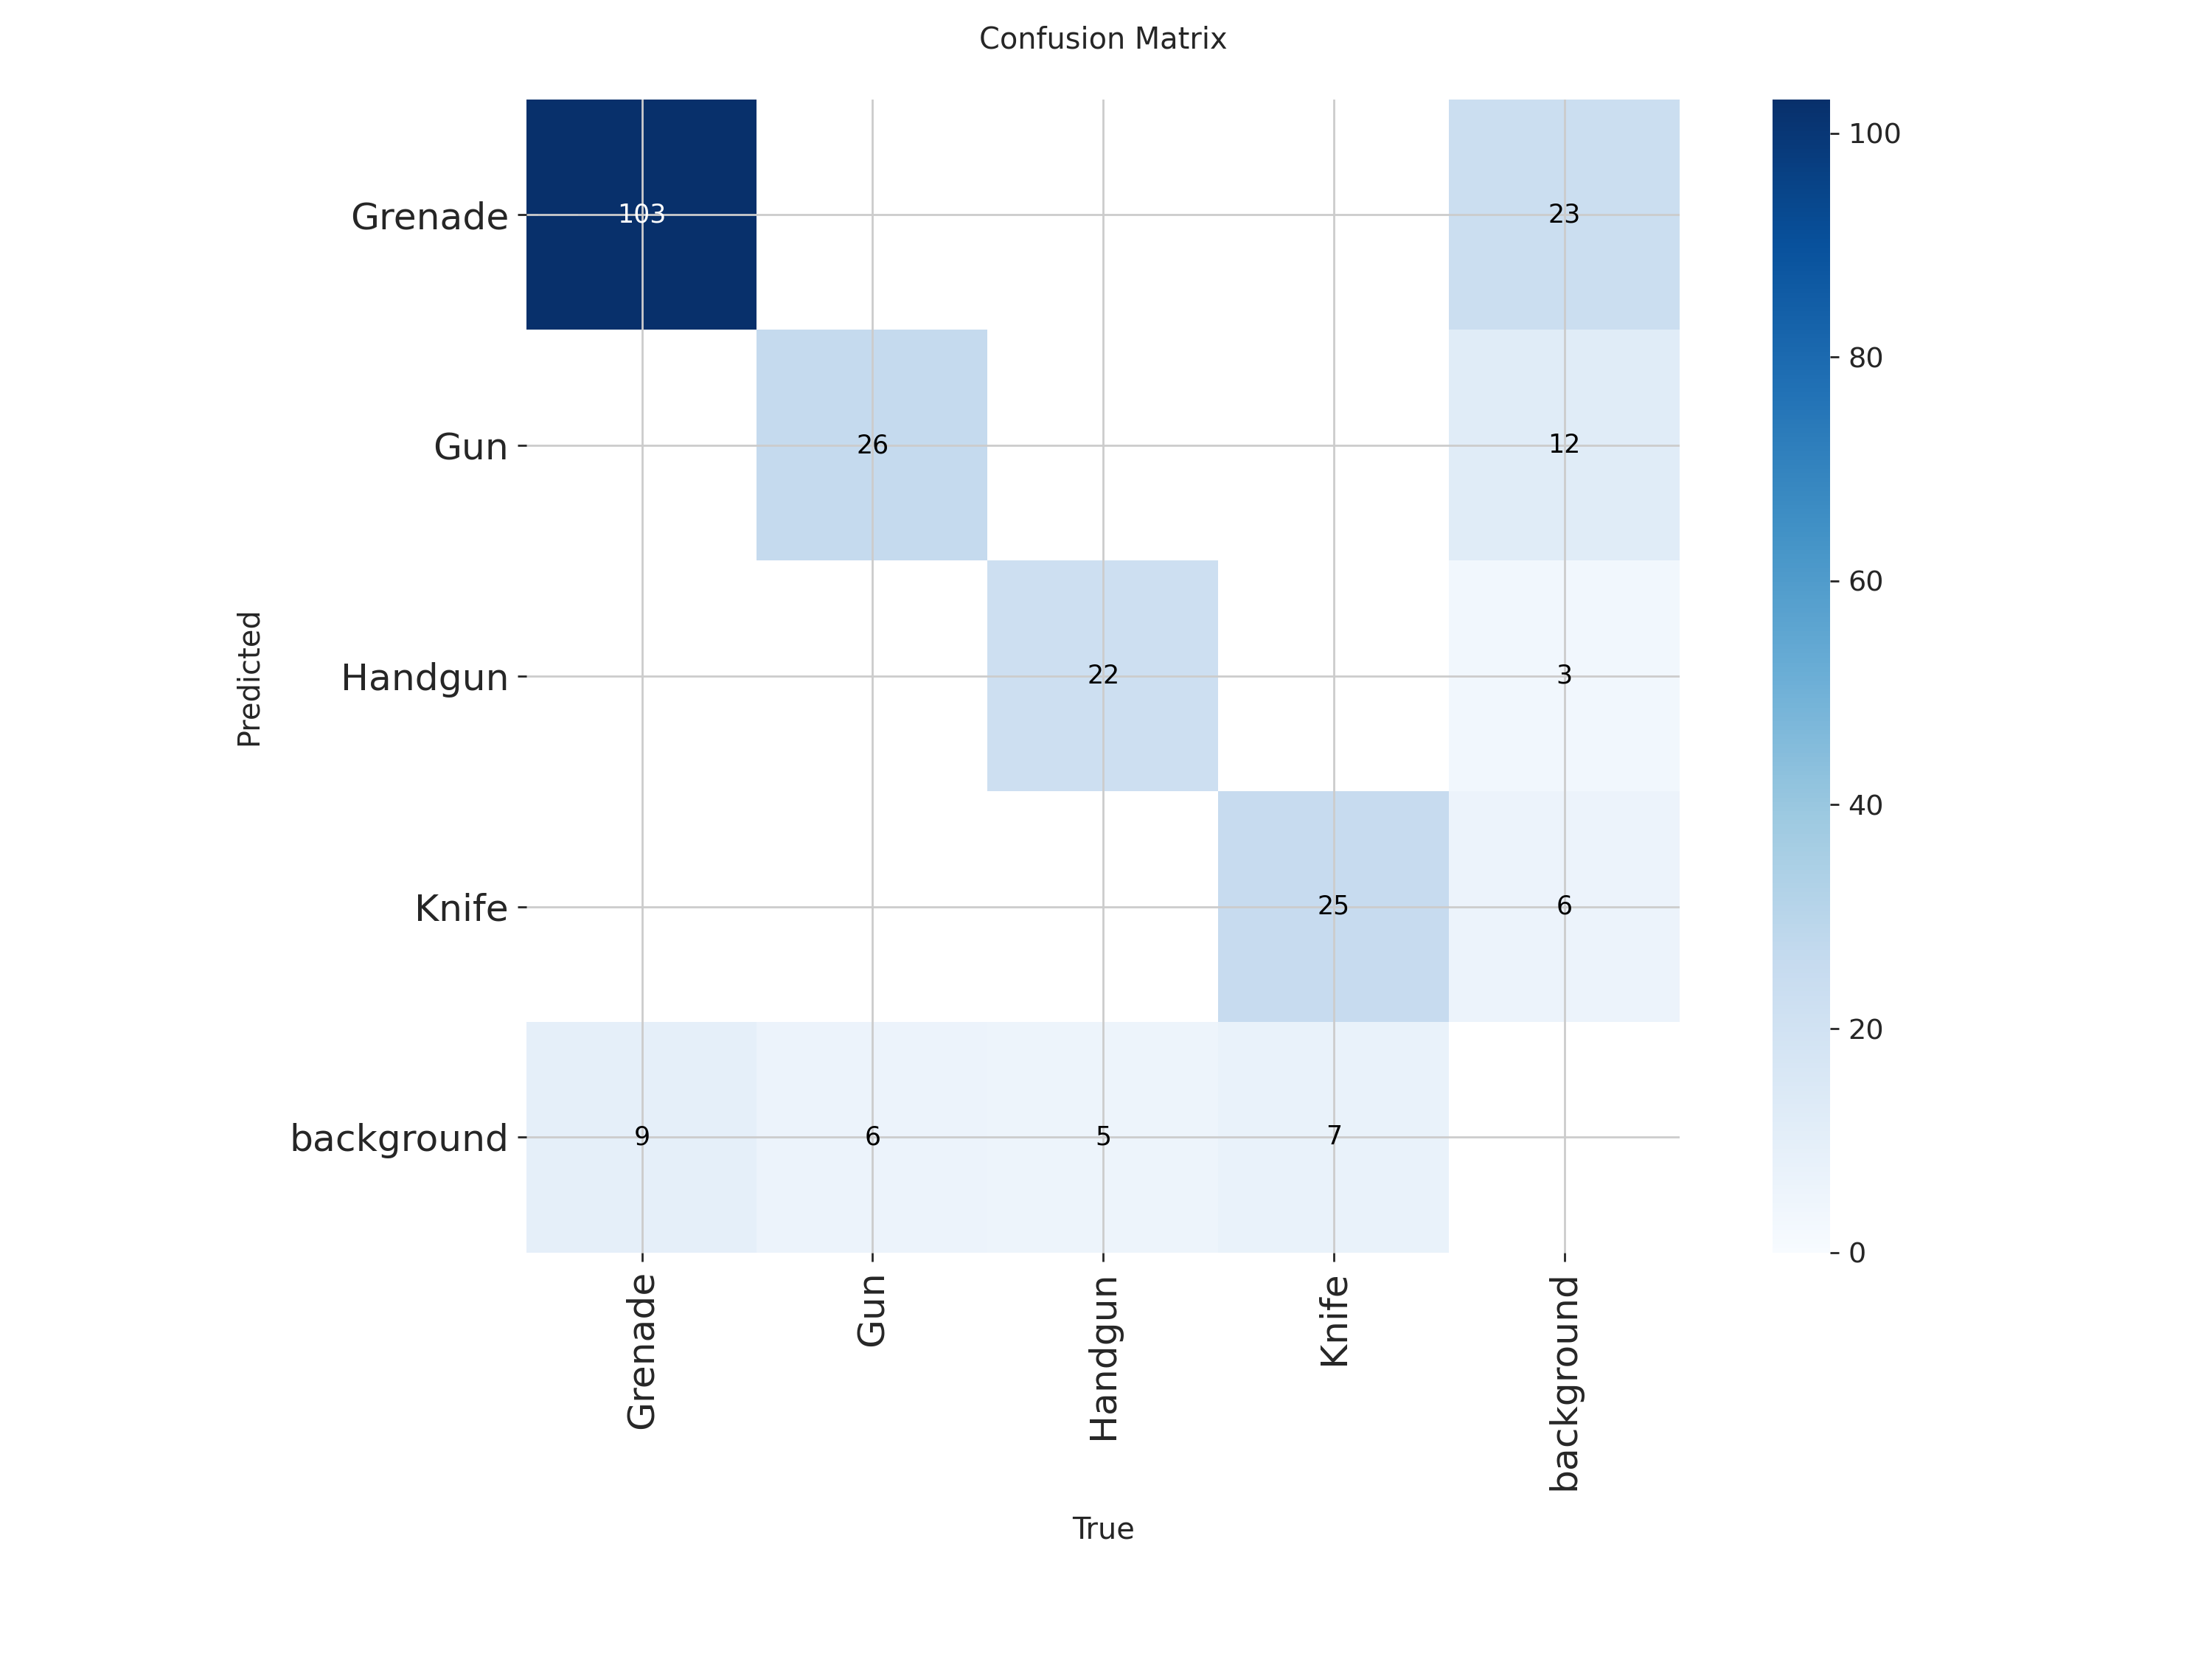

In [10]:
# Validate the model on the test dataset
metrics = model.val()

# Print mAP scores for different thresholds
print(f"mAP@0.5: {metrics.box.map50:.4f}")  # mAP at IoU=0.5
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")  # mAP at IoU=0.5 to 0.95

# Plot confusion matrix if available
cm = "/kaggle/working/runs/wepon_detection/confusion_matrix.png"
if Path(cm).exists():
    display(Image(cm))


In [11]:
# Perform inference on the test images (use your test dataset path)
results = model.predict(
    source="/kaggle/working/teting_generade_weapon-1/test/images",  # Path to your test dataset
    imgsz=640,  # The image size used during training
    conf=0.25,  # Confidence threshold for filtering predictions
    iou=0.45,  # IOU threshold for NMS
    device=0 if torch.cuda.is_available() else "cpu",  # Use GPU if available, otherwise CPU
    save=True,  # Save predictions (images with bounding boxes)
    save_txt=True,  # Save predictions to text files
    save_conf=True  # Save confidence scores
)

# Print results
print(f"Results on test data: {results}")



image 1/44 /kaggle/working/teting_generade_weapon-1/test/images/0bf4836b-ep132_jpg.rf.d81369f26c997aab7bef6885dfe46095.jpg: 640x640 2 Grenades, 10.9ms
image 2/44 /kaggle/working/teting_generade_weapon-1/test/images/0cf232d02fa6bf7de5b21d84cdbdbf8f_jpg.rf.472e8d78e7620bfab6c16cefd9df9818.jpg: 640x640 5 Grenades, 1 Gun, 1 Knife, 7.9ms
image 3/44 /kaggle/working/teting_generade_weapon-1/test/images/0e1c0b3b1ee9b041c5861d05d9611594_jpg.rf.908e0d6cec04c3d2d0fed4373d1c2f27.jpg: 640x640 6 Grenades, 1 Gun, 7.9ms
image 4/44 /kaggle/working/teting_generade_weapon-1/test/images/1000_F_201263720_SzsdIbkCkz1yT9KMIpLtiFfmF70fqZC8_jpg.rf.6ad7186f1f37a8dc8ba9584b65f90859.jpg: 640x640 1 Gun, 1 Knife, 7.8ms
image 5/44 /kaggle/working/teting_generade_weapon-1/test/images/12267256023_f44511e40f_b_jpg.rf.e5aca193676800164037d528768cba18.jpg: 640x640 1 Grenade, 1 Knife, 7.7ms
image 6/44 /kaggle/working/teting_generade_weapon-1/test/images/15d17e8ac1a50904fea2dd1836eed323_jpg.rf.b90893039551343350637f96f936

## Overfitting & Underfitting comparion
## ──────────────────────────────────────────────────────────────

Available columns:
 ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


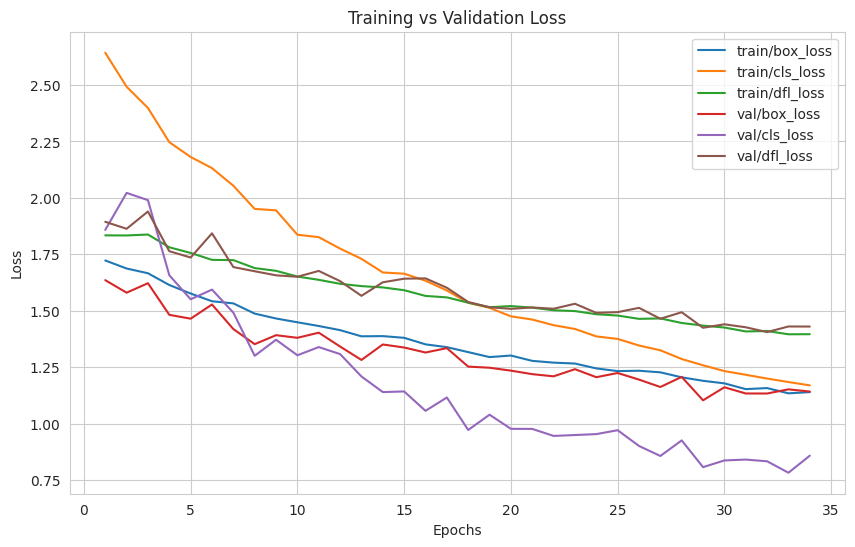

Detected mAP columns: []
✅  Model seems well-fitted (balanced losses).


In [14]:
# Path to your training logs CSV generated by YOLO during training
results_csv = Path("/kaggle/working/runs/wepon_detection/results.csv")

# Load the CSV into a pandas DataFrame for analysis
df = pd.read_csv(results_csv)

# Print all column names to see which metrics are available (losses, mAP, etc.)
print("Available columns:\n", list(df.columns))

# --- Plot training vs validation losses ---

# Select all columns related to training losses (contain 'train' and 'loss')
loss_cols = [c for c in df.columns if "train" in c and "loss" in c]

# Select all columns related to validation losses (contain 'val' and 'loss')
val_cols  = [c for c in df.columns if "val" in c and "loss" in c]

# Create a figure for plotting loss curves
plt.figure(figsize=(10,6))

# Plot each training loss curve against epochs
for col in loss_cols:
    plt.plot(df["epoch"], df[col], label=col)

# Plot each validation loss curve against epochs
for col in val_cols:
    plt.plot(df["epoch"], df[col], label=col)

# Label X-axis as Epochs
plt.xlabel("Epochs")

# Label Y-axis as Loss
plt.ylabel("Loss")

# Title of the plot
plt.title("Training vs Validation Loss")

# Show legend for curves
plt.legend()

# Display the plot
plt.show()

# --- Detect which mAP columns exist ---

# Find all columns that contain 'mAP' (case-insensitive) in the CSV
map_cols = [c for c in df.columns if "mAP" in c.lower()]

# Print detected mAP columns
print("Detected mAP columns:", map_cols)

# --- Simple overfit/underfit indicator using last box losses ---

# Extract the last epoch's training box loss
train_box = df[[c for c in df.columns if "train/box" in c]].iloc[-1].values[0]

# Extract the last epoch's validation box loss
val_box   = df[[c for c in df.columns if "val/box" in c]].iloc[-1].values[0]

# Check for overfitting: val loss significantly higher than train loss
if val_box > train_box * 1.3:
    print("⚠️  Model may be overfitting (val loss much higher).")

# Check for underfitting: val loss significantly lower than train loss
elif val_box < train_box * 0.7:
    print("⚠️  Possible underfitting (val loss lower than train loss).")

# Otherwise, losses are balanced → likely well-fitted
else:
    print("✅  Model seems well-fitted (balanced losses).")


## Acuracy Comparison 
-----

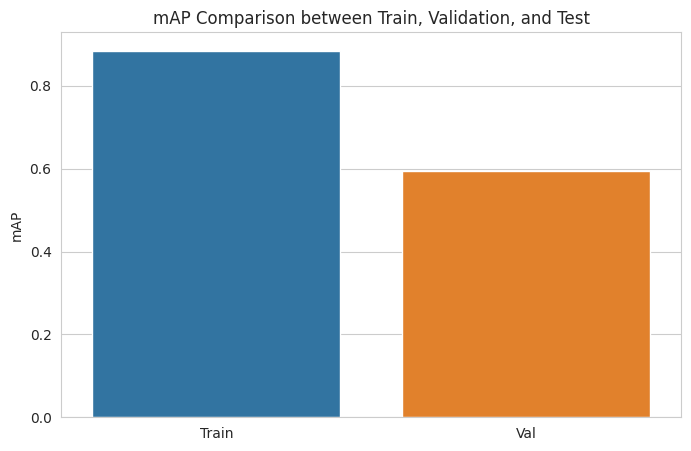

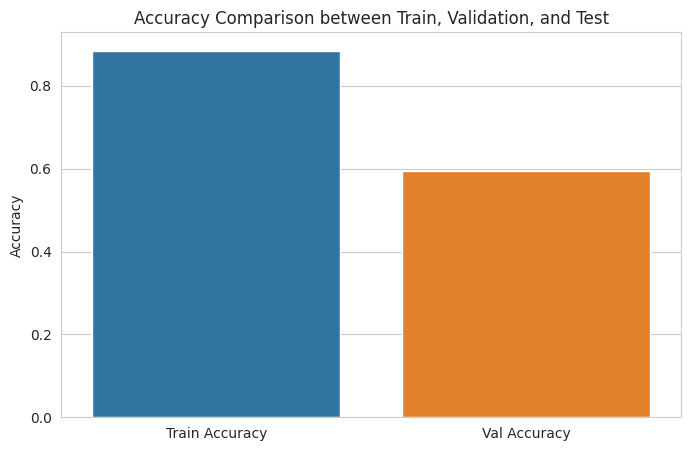

In [17]:
# Plot the mAP scores comparison between training, validation, and test
plt.figure(figsize=(8, 5))
sns.barplot(x=["Train", "Val"], y=[metrics.box.map50, metrics.box.map])  # Using map50 for comparison
plt.title("mAP Comparison between Train, Validation, and Test")
plt.ylabel("mAP")
plt.show()

# For training accuracy comparison, plot it against validation and test accuracy
plt.figure(figsize=(8, 5))
sns.barplot(x=["Train Accuracy", "Val Accuracy"], y=[metrics.box.map50, metrics.box.map])  # Assuming map50 as accuracy for comparison
plt.title("Accuracy Comparison between Train, Validation, and Test")
plt.ylabel("Accuracy")
plt.show()

## Display Sample Prediction
------


image 1/1 /kaggle/working/teting_generade_weapon-1/test/images/FILE806_JPG_jpg.rf.5cddfcc1795c9f44729f2b104c49607e.jpg: 640x640 1 Grenade, 2 Handguns, 215.4ms
Speed: 1.7ms preprocess, 215.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


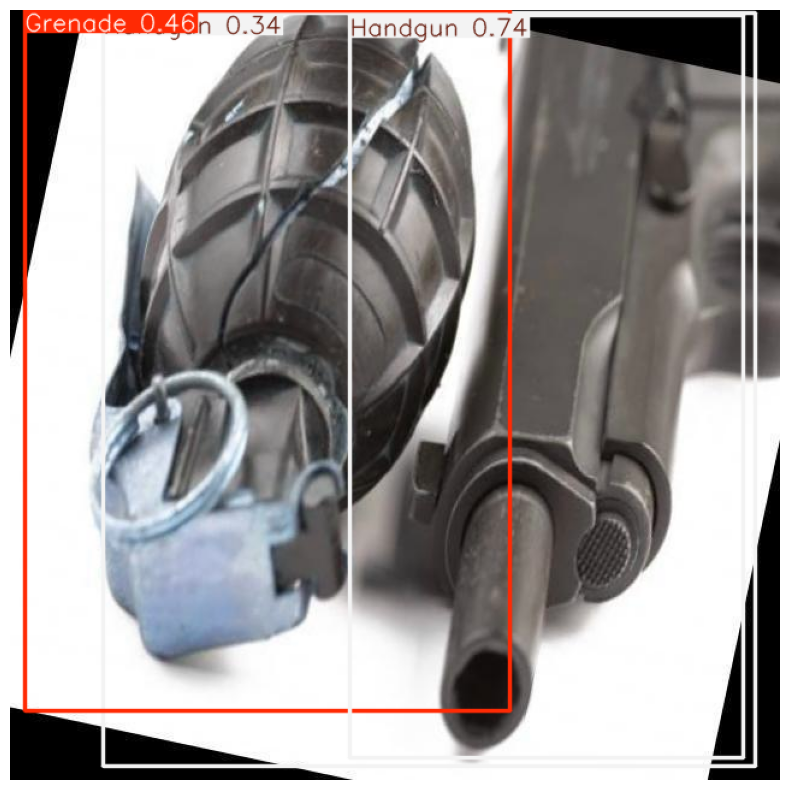

In [18]:
from IPython.display import display
import matplotlib.pyplot as plt
from PIL import Image

# Load the YOLO model and force it to use CPU
model = YOLO("/kaggle/working/runs/wepon_detection/weights/best.pt")  # Adjust path if necessary
model.to('cpu')  # Force the model to run on CPU

# Define the test image path
test_img_path = r"/kaggle/working/teting_generade_weapon-1/test/images/FILE806_JPG_jpg.rf.5cddfcc1795c9f44729f2b104c49607e.jpg"

# Perform detection (prediction) on the test image
results = model(test_img_path)

# Access the first result from the list of results
result = results[0]

# Visualize the result with the image and predictions
img = result.plot()  # This will return the image with bounding boxes

# Convert image to RGB if it's in a different format
img_rgb = Image.fromarray(img).convert('RGB')

# Display the image inline in the notebook using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')  # Hide axis
plt.show()


In [19]:
!zip -r /kaggle/working/wepon_det_yolov11 /kaggle/working/runs/

  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/wepon_detection/ (stored 0%)
  adding: kaggle/working/runs/wepon_detection/BoxR_curve.png (deflated 9%)
  adding: kaggle/working/runs/wepon_detection/val_batch2_labels.jpg (deflated 16%)
  adding: kaggle/working/runs/wepon_detection/BoxF1_curve.png (deflated 7%)
  adding: kaggle/working/runs/wepon_detection/BoxPR_curve.png (deflated 14%)
  adding: kaggle/working/runs/wepon_detection/val_batch0_labels.jpg (deflated 9%)
  adding: kaggle/working/runs/wepon_detection/val_batch1_labels.jpg (deflated 13%)
  adding: kaggle/working/runs/wepon_detection/args.yaml (deflated 52%)
  adding: kaggle/working/runs/wepon_detection/labels.jpg (deflated 25%)
  adding: kaggle/working/runs/wepon_detection/train_batch0.jpg (deflated 12%)
  adding: kaggle/working/runs/wepon_detection/results.png (deflated 7%)
  adding: kaggle/working/runs/wepon_detection/val_batch2_pred.jpg (deflated 16%)
  adding: kaggle/working/runs/wepon_detection/va

In [20]:
!zip -r /kaggle/working/wepon_detection_dataset /kaggle/working/teting_generade_weapon-1

  adding: kaggle/working/teting_generade_weapon-1/ (stored 0%)
  adding: kaggle/working/teting_generade_weapon-1/data.yaml (deflated 37%)
  adding: kaggle/working/teting_generade_weapon-1/valid/ (stored 0%)
  adding: kaggle/working/teting_generade_weapon-1/valid/labels/ (stored 0%)
  adding: kaggle/working/teting_generade_weapon-1/valid/labels/xavier-jou-menu-war_jpg.rf.8a785d46500f76e5285f4ec8dd20497a.txt (deflated 34%)
  adding: kaggle/working/teting_generade_weapon-1/valid/labels/5d88ff11-ep266_jpg.rf.f23080a0934c6778455330a6bfc51fa4.txt (deflated 12%)
  adding: kaggle/working/teting_generade_weapon-1/valid/labels/2d42d343-e1427_jpg.rf.76989323472b76271cbdc0bd2178252d.txt (deflated 20%)
  adding: kaggle/working/teting_generade_weapon-1/valid/labels/Screenshot-from-2022-07-27-10-48-23_png_jpg.rf.2dd5462b81aba1ee6690922dea277e71.txt (deflated 51%)
  adding: kaggle/working/teting_generade_weapon-1/valid/labels/24eccfaf-e1168_jpg.rf.a59c6c1d3c140e7b158402dacf3a5930.txt (deflated 18%)
  